**Edited By Saeed**

# CDS2413 Data Analysis Project
Student Habits & Performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_1samp

df = pd.read_csv('student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## Descriptive Statistics Function

In [2]:
def descriptive_stats(data, column):
    return {
        "Mean": data[column].mean(),
        "Median": data[column].median(),
        "Mode": data[column].mode()[0],
        "Std": data[column].std(),
        "Min": data[column].min(),
        "Max": data[column].max()
    }

descriptive_stats(df, "exam_score")

{'Mean': np.float64(69.6015),
 'Median': 70.5,
 'Mode': np.float64(100.0),
 'Std': 16.88856392181825,
 'Min': 18.4,
 'Max': 100.0}

## Random Sampling

In [3]:
sample_random = df.sample(n=150, random_state=42)
descriptive_stats(sample_random, "exam_score")

{'Mean': np.float64(68.65599999999999),
 'Median': 70.65,
 'Mode': np.float64(83.3),
 'Std': 16.046365203422567,
 'Min': 18.4,
 'Max': 100.0}

## Systematic Sampling

In [4]:
step = len(df)//150
sample_systematic = df.iloc[::step]
descriptive_stats(sample_systematic, "exam_score")

{'Mean': np.float64(69.15928143712574),
 'Median': 68.4,
 'Mode': np.float64(100.0),
 'Std': 15.118113908661217,
 'Min': 31.5,
 'Max': 100.0}

## Visualizations

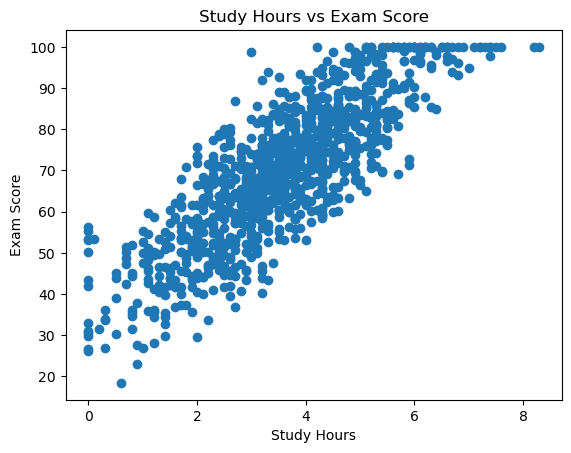

In [5]:
plt.scatter(df["study_hours_per_day"], df["exam_score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()

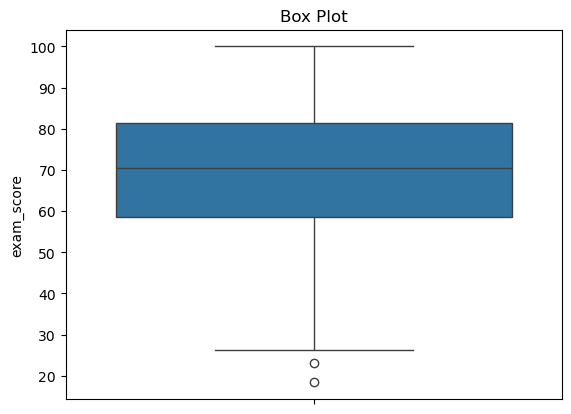

In [6]:
sns.boxplot(y=df["exam_score"])
plt.title("Box Plot")
plt.show()

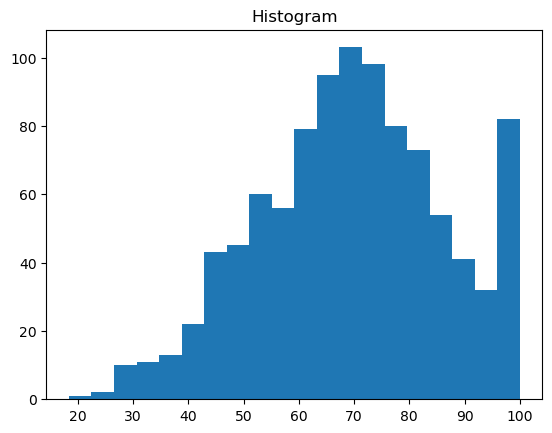

In [7]:
plt.hist(df["exam_score"], bins=20)
plt.title("Histogram")
plt.show()

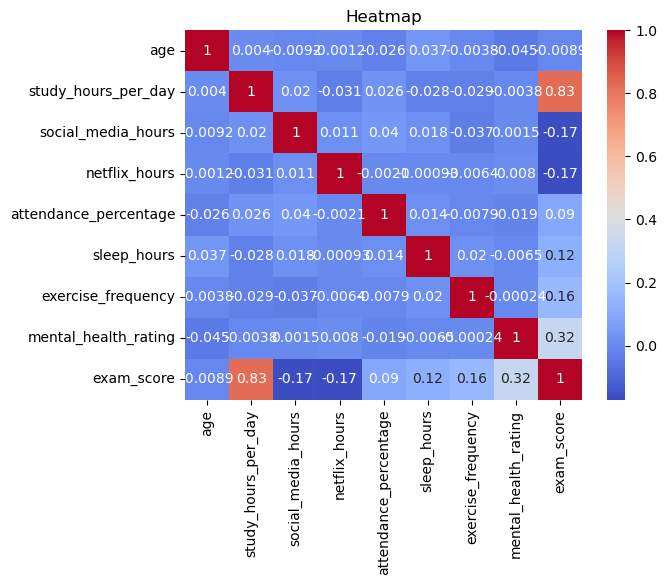

In [8]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heatmap")
plt.show()

## Hypothesis Testing

In [9]:
corr, p = pearsonr(df["study_hours_per_day"], df["exam_score"])
print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.8254185093960442
P-value: 4.595701453345378e-250


## One Sample T-Test

In [10]:
t_stat, p_val = ttest_1samp(df["exam_score"], 70)
print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: -0.7461662539282511
P-value: 0.45574253492548966
